In [1]:
%cd /home/smaniyar_umass_edu/BioNLP_Ontology/lf/LLaMA-Factory


/home/smaniyar_umass_edu/BioNLP_Ontology/lf/LLaMA-Factory


In [3]:
import torch
try:
  assert torch.cuda.is_available() is True
except AssertionError:
  print("Please set up a GPU before using LLaMA Factory")

In [5]:
import json

with open('/home/smaniyar_umass_edu/BioNLP_Ontology/other/nlp/privacyQA/data/training/PrivacyQA_training.json', 'r', encoding='utf-8') as f:
    data = json.load(f)


In [11]:
import json
import random
from collections import Counter

# Load your data
with open("/home/smaniyar_umass_edu/BioNLP_Ontology/other/nlp/privacyQA/data/training/PrivacyQA_training.json", "r") as f:
    data = json.load(f)

# Separate by label
relevant = [d for d in data if d["output"].strip().upper() == "RELEVANT"]
irrelevant = [d for d in data if d["output"].strip().upper() == "IRRELEVANT"]

# Show ratio in full dataset
total = len(data)
counts = Counter(d["output"].strip().upper() for d in data)
print(f"Full dataset size: {total}")
print("Label counts:", counts)

# Desired total sample size
sample_size = 32000



n_rel = 7137
n_irr = sample_size - n_rel  # ensures total = 64000

print(f"Sampling {n_rel} RELEVANT and {n_irr} IRRELEVANT")
# Stratified random sampling (reproducible)
random.seed(42)
sampled = relevant+ random.sample(irrelevant, n_irr)
random.shuffle(sampled)

# Save to file
with open("/home/smaniyar_umass_edu/BioNLP_Ontology/other/nlp/privacyQA/data/training/privacyqa_32k_7k_relevant_rest_irrelevant.json", "w") as f:
    json.dump(sampled, f, indent=2, ensure_ascii=False)

print("✅ Saved stratified dataset with 64,000 samples to privacyqa_32k_7k_relevant_rest_irrelevant.json")


Full dataset size: 185200
Label counts: Counter({'IRRELEVANT': 178063, 'RELEVANT': 7137})
Sampling 7137 RELEVANT and 24863 IRRELEVANT
✅ Saved stratified dataset with 64,000 samples to privacyqa_32k_7k_relevant_rest_irrelevant.json


In [8]:
len(relevant)

7137

In [6]:
len(data)

185200

In [13]:
import json

args = dict(
  stage="sft",                                               # do supervised fine-tuning
  do_train=True,
  model_name_or_path="meta-llama/Llama-3.2-3B-Instruct", # use bnb-4bit-quantized Llama-3-8B-Instruct model
  dataset="privacy_qa_7k_rel_32k",                         # use alpaca and identity datasets
  template="llama3",                                         # use llama3 prompt template
  finetuning_type="lora",                                    # use LoRA adapters to save memory
  lora_target="all",                                         # attach LoRA adapters to all linear layers
  output_dir="privacyqa_llama_7k_rel_32k",                                  # the path to save LoRA adapters
  per_device_train_batch_size=64,                             # the micro batch size
  gradient_accumulation_steps=2,                             # the gradient accumulation steps
  lr_scheduler_type="cosine",                                # use cosine learning rate scheduler
  logging_steps=640,                                           # log every 5 steps
  warmup_ratio=0.1,                                          # use warmup scheduler
  save_steps=8000,                                           # save checkpoint every 1000 steps
  learning_rate=5e-5,                                        # the learning rate
  num_train_epochs=2.0,                                      # the epochs of training
  max_samples=32000,                                          
  max_grad_norm=1.0,                                         # clip gradient norm to 1.0
  loraplus_lr_ratio=16.0,                                    # use LoRA+ algorithm with lambda=16.0
  fp16=True,                                                 # use float16 mixed precision training
  report_to="none",                                          # disable wandb logging
)

json.dump(args, open("/home/smaniyar_umass_edu/BioNLP_Ontology/lf/LLaMA-Factory/privacyqa_llama_7k_rel_32k.json", "w", encoding="utf-8"), indent=2)



In [10]:
% cd /home/smaniyar_umass_edu/BioNLP_Ontology/lf/LLaMA-Factory

UsageError: Line magic function `%` not found.


In [13]:
!llamafactory-cli train train_llama_privacyqa.json

/work/pi_hongyu_umass_edu/smaniyar_umass_edu-conda/envs/llamafactoryenv/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[INFO|2025-11-04 04:26:47] llamafactory.hparams.parser:455 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.float16
[INFO|tokenization_utils_base.py:2095] 2025-11-04 04:26:47,306 >> loading file tokenizer.json from cache at /home/smaniyar_umass_edu/.cache/huggingface/hub/models--meta-llama--Llama-3.2-3B-Instruct/snapshots/0cb88a4f764b7a12671c53f0838cd831a0843b95/tokenizer.json
[INFO|tokenization_utils_base.py:2095] 2025-11-04 04:26:47,306 >> loading file tokenizer.model from cache at None
[INFO|tokenization_utils_base.py:2095] 2025-11-04 04:26:47,306 >> l

=== Evaluation Results ===
Total evaluated samples: 999 / 999
Accuracy       : 0.9069
F1 (macro)     : 0.6628
F1 (weighted)  : 0.8928

Confusion Matrix (raw counts):
            RELEVANT  IRRELEVANT
RELEVANT          28          71
IRRELEVANT        22         878

Normalized Confusion Matrix (fractions):
            RELEVANT  IRRELEVANT
RELEVANT      0.2828      0.7172
IRRELEVANT    0.0244      0.9756

Detailed Classification Report (fractions):
              precision    recall  f1-score   support

  IRRELEVANT   0.925184  0.975556  0.949703       900
    RELEVANT   0.560000  0.282828  0.375839        99

    accuracy                       0.906907       999
   macro avg   0.742592  0.629192  0.662771       999
weighted avg   0.888995  0.906907  0.892833       999



/tmp/ipykernel_1598608/553588461.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


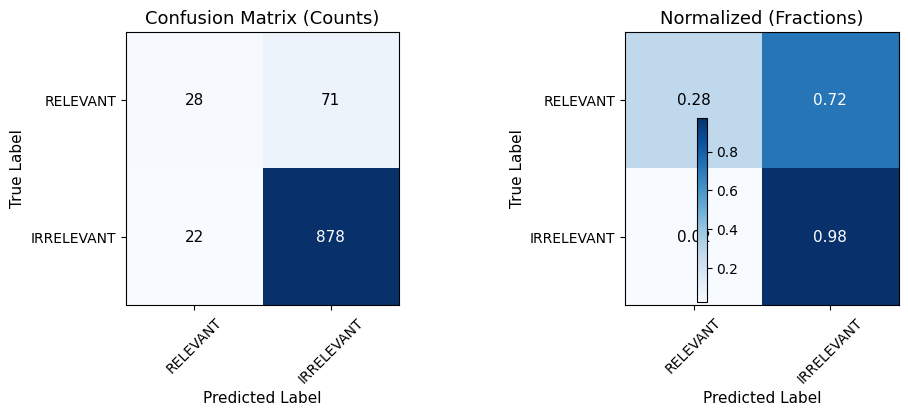

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# -------------------------------
# 1. USER INPUTS
# -------------------------------
pred_path = "/home/smaniyar_umass_edu/BioNLP_Ontology/other/nlp/meta-enriched-rag-for-legal-llms/privacyQA/test_results/finetned_llama3b/predictions.csv"

# -------------------------------
# 2. LOAD DATA
# -------------------------------
df_pred = pd.read_csv(pred_path)

# Normalize label text
df_pred["GT"] = df_pred["GT"].astype(str).str.strip().str.upper()
df_pred["ExtractedOutput"] = df_pred["ExtractedOutput"].astype(str).str.strip().str.upper()

# -------------------------------
# 3. FILTER VALID LABELS
# -------------------------------
valid_labels = {"RELEVANT", "IRRELEVANT"}
filtered = df_pred[
    df_pred["GT"].isin(valid_labels) &
    df_pred["ExtractedOutput"].isin(valid_labels)
]

y_true = filtered["GT"]
y_pred = filtered["ExtractedOutput"]
labels = ["RELEVANT", "IRRELEVANT"]

# -------------------------------
# 4. METRICS
# -------------------------------
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

# -------------------------------
# 5. PRINT RESULTS
# -------------------------------
print("=== Evaluation Results ===")
print(f"Total evaluated samples: {len(filtered)} / {len(df_pred)}")
print(f"Accuracy       : {acc:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")

print("\nConfusion Matrix (raw counts):")
print(pd.DataFrame(cm, index=labels, columns=labels))

print("\nNormalized Confusion Matrix (fractions):")
print(pd.DataFrame(cm_norm, index=labels, columns=labels).round(4))

print("\nDetailed Classification Report (fractions):")
print(classification_report(y_true, y_pred, digits=6))

# -------------------------------
# 6. PLOT CONFUSION MATRICES
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
titles = ["Confusion Matrix (Counts)", "Normalized (Fractions)"]
mats = [cm, cm_norm]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=13)
    tick_marks = range(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)

    # Add text annotations
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            text = f"{mat[i, j]:.2f}" if mat is cm_norm else str(mat[i, j])
            ax.text(j, i, text,
                    ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() / 2 else "black",
                    fontsize=11)

    ax.set_ylabel("True Label", fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()


In [10]:
f1_binary = f1_score(y_true, y_pred, pos_label="RELEVANT")
print(f"F1 (RELEVANT only): {f1_binary:.4f}")


F1 (RELEVANT only): 0.3758
